# Production Graph RAG for the Enterprise
## Vector RAG vs SQL+RAG vs Graph RAG: A Food Safety Supply Chain Showdown

**Google Cloud DACH AI Summit — Frankfurt**

This notebook demonstrates why **Graph RAG** with Spanner Graph delivers auditable, precise, time-aware answers that Vector RAG and relational SQL+RAG cannot match.

We use a **food contamination crisis** scenario — E. coli detected in a lettuce batch — and ask **seven** escalating questions that mirror a real health authority investigation. Three architectures answer the same questions using the same underlying data.

### The Epiquant (Epistemic-Quantitative) Paradigm

Traditional Vector RAG systems are **epistemically blind** and **quantitatively illiterate**:
1. **Epistemic Blindness**: They search for "semantic similarity," not topological truth. They cannot distinguish between a fact that was true in the world at 10:00 AM versus a fact recorded in the database at 11:00 AM (temporal/bi-temporal tracking).
2. **Quantitative Illiteracy**: They cannot perform math or follow quantitative flows. If 120kg of lettuce is split into 40kg, 25kg, and 8kg, Vector RAG cannot subtract, aggregate, or calculate consumer exposure based on those values.
3. **Lattice Deficit**: They cannot traverse supply chains. A supply chain is a directed lattice of dependencies. Vector RAG is limited to flat keyword proximity.

To solve this, we apply the **Epistemic-Quantitative Lattice Store (EQLS)** principles:

| Epiquant / EQLS Principle | Supply Chain Adaptation | Why Vector RAG Fails |
|---|---|---|
| **Epistemic Tracking** | Valid Time vs. System Time on edges | Cannot reason about timestamps or database write order |
| **Quantitative Flows** | Quantity, weight, and exposure rate propagation | Cannot perform math or trace product volume division |
| **Lattice Topology** | Farms & retailers = Hubs; Deliveries = Spokes | Limited to semantic distance; cannot traverse path structures |
| **Structural Pivots** | Same-warehouse/supplier logical links | Cannot link disjoint documents that lack semantic similarity |

### The 7 Questions

| # | Question | Complexity | Why Vector RAG Struggles |
|---|---|---|---|
| Q1 | Which retailers received the contaminated batch? | Simple trace | Misses retail locations if document chunks fall outside top-k |
| Q2 | Trace the full chain from farm to shelf | Variable-depth traversal | Broken path: cannot join 5+ disjoint document chunks |
| Q3 | Which deliveries went through the compromised warehouse? | Temporal reasoning | Cannot perform date/time comparisons on text |
| Q4 | What OTHER products went through that warehouse? | Lateral pivot | Cannot connect unrelated products sharing a warehouse node |
| Q5 | Find common supply chain entities (up to 3 hops) | Graph traversal | Cannot resolve multi-hop backward paths between entities |
| Q6 | Show the audit trail for the regulatory filing | Provenance / path as proof | Returns prose, not structured mathematical paths |
| Q7 | Perform bi-temporal compliance audit (8:30 vs 10:00 AM) | Bi-temporal tracking | Cannot recreate database states as they existed at a specific time |

### RAG Architectures Comparison Infographic

Here is an architectural map of how each RAG variant processes the supply chain data:

![Comparison of RAG Architectures](https://raw.githubusercontent.com/salekh/cloud-summit-dach-2026/main/infographics/rag_comparison_infographic.png)

---

⏱️ **Session Duration: ~60-75 minutes** | 💰 Infrastructure is pre-provisioned

## 0. Environment Setup

Install required packages and authenticate. This notebook works in:
- ✅ Google Colab
- ✅ Colab Enterprise (Vertex AI Workbench)
- ✅ Local Jupyter with Application Default Credentials

In [ ]:
# Install dependencies (restart kernel after if needed)
!pip install -q --index-url https://pypi.org/simple/     google-cloud-spanner google-cloud-aiplatform google-cloud-storage     plotly pyvis networkx "google-genai[pyopenssl]>=2.4.0" langchain-google-spanner

In [1]:
# Authentication — auto-detect environment
import sys
import os

def authenticate():
    """Authenticate based on detected environment."""
    # Colab / Colab Enterprise
    try:
        from google.colab import auth
        auth.authenticate_user()
        print("✅ Authenticated via Colab.")
        return
    except ImportError:
        pass

    # Local Jupyter — check for ADC
    adc_path = os.path.expanduser("~/.config/gcloud/application_default_credentials.json")
    if os.path.exists(adc_path):
        print("✅ Using Application Default Credentials (ADC).")
        return

    print("⚠️  No credentials found. Run: gcloud auth application-default login")

authenticate()

✅ Authenticated via Colab.


In [3]:
# Imports
import json
import textwrap
from datetime import datetime, timezone, timedelta
from collections import defaultdict
from IPython.display import HTML, display, Markdown

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from google.cloud import spanner
from google import genai
from google.genai import types
import langchain_google_spanner

# Configuration
PROJECT_ID = ""  # @param {type:"string"}
REGION = "europe-west3"  # @param {type:"string"}
AI_REGION = "global"  # @param {type:"string"}

# Pre-provisioned Spanner (shared instance for all participants)
SPANNER_INSTANCE_ID = "food-safety-demo"  # @param {type:"string"}
SPANNER_DATABASE_ID = "supply-chain-graph"  # @param {type:"string"}

# Gemini
GEMINI_MODEL = "gemini-3.5-flash"  # @param {type:"string"}

# Set project
if not PROJECT_ID:
    PROJECT_ID = os.environ.get("GOOGLE_CLOUD_PROJECT", "")

if PROJECT_ID:
    !gcloud config set project {PROJECT_ID} --quiet 2>/dev/null
    os.environ["GOOGLE_CLOUD_PROJECT"] = PROJECT_ID

# Initialize clients
spanner_client = spanner.Client(project=PROJECT_ID or None)
gemini_client = genai.Client(vertexai=True, project=PROJECT_ID or None, location=AI_REGION)

def extract_text_from_response(response) -> str:
    if not response:
        return "None (Empty response)"
    if hasattr(response, 'text') and response.text:
        return response.text
    if hasattr(response, 'candidates') and response.candidates:
        cand = response.candidates[0]
        if hasattr(cand, 'content') and cand.content and cand.content.parts:
            text_parts = []
            for part in cand.content.parts:
                if hasattr(part, 'text') and part.text:
                    text_parts.append(part.text)
            if text_parts:
                return "".join(text_parts)
        finish_reason = getattr(cand, 'finish_reason', 'UNKNOWN')
        return f"None (Finish reason: {finish_reason})"
    return "None (No candidates returned)"

print(f"✅ Config: project={PROJECT_ID}, region={REGION}, ai_region={AI_REGION}")
print(f"   Spanner: {SPANNER_INSTANCE_ID}/{SPANNER_DATABASE_ID}")
print(f"   Model: {GEMINI_MODEL}")

✅ Config: project=sa-learning-1, region=europe-west3, ai_region=global
   Spanner: food-safety-demo/supply-chain-graph
   Model: gemini-3.5-flash


## 1. The Scenario — Monday Morning in Frankfurt

> **🚨 It's Monday, March 4th, 2024. 8:47 AM.**
>
> Your phone rings. It's the **Gesundheitsamt Frankfurt** (public health authority).
>
> *"E. coli O157:H7 confirmed in romaine lettuce samples from Farm 'Grünfeld Hof', Batch #L-2024-0312, shipped March 3rd. We need to know: which restaurants and supermarkets in Frankfurt received this batch, and how many consumers are potentially affected. You have two hours before we issue a public alert."*

Every German over 30 remembers the **2011 EHEC crisis** — 53 deaths, sprouts traced through a supply chain. This is not theoretical.

### The Supply Chain


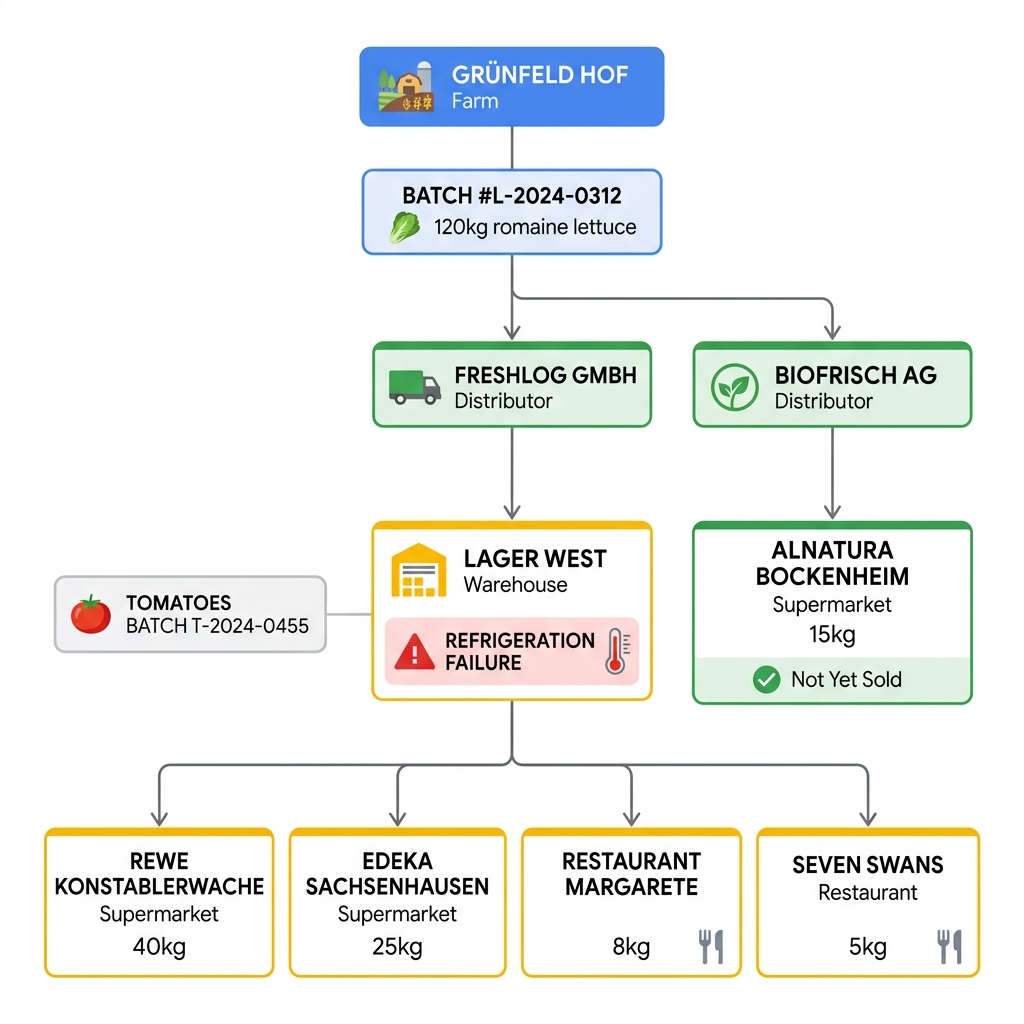

In [1]:
from PIL import Image
import urllib.request

# Load and display infographic from GitHub
url = "https://raw.githubusercontent.com/salekh/cloud-summit-dach-2026/main/infographics/supply_chain_infographic.png"
img = Image.open(urllib.request.urlopen(url))
img


**Let's see how three different architectures handle this crisis.**


In [4]:
# ================================================================
# SYNTHETIC SUPPLY CHAIN DATA
# Same facts, three different storage formats
# ================================================================

SUPPLY_CHAIN = {
    "farms": [
        {"id": "farm-001", "name": "Grünfeld Hof", "region": "Hessen", "type": "organic",
         "products": ["romaine lettuce", "spinach", "arugula"],
         "certifications": [{"type": "EU-Bio", "valid_from": "2023-01-01", "valid_to": "2025-12-31"}]},
        {"id": "farm-002", "name": "Sonnenhof Wetterau", "region": "Hessen", "type": "conventional",
         "products": ["cherry tomatoes", "bell peppers", "cucumbers"]},
        {"id": "farm-003", "name": "Biohof Rheingau", "region": "Hessen", "type": "organic",
         "products": ["herbs", "salad mix"]},
    ],
    "batches": [
        {"id": "L-2024-0312", "farm_id": "farm-001", "product": "Romaine Lettuce",
         "harvest_date": "2024-03-02", "shipped_date": "2024-03-03",
         "quantity_kg": 120, "contaminated": True, "contaminant": "E. coli O157:H7"},
        {"id": "T-2024-0455", "farm_id": "farm-002", "product": "Cherry Tomatoes",
         "harvest_date": "2024-03-02", "shipped_date": "2024-03-03",
         "quantity_kg": 80, "contaminated": False},
        {"id": "H-2024-0501", "farm_id": "farm-003", "product": "Fresh Herbs",
         "harvest_date": "2024-03-03", "shipped_date": "2024-03-04",
         "quantity_kg": 30, "contaminated": False},
        {"id": "S-2024-0288", "farm_id": "farm-001", "product": "Baby Spinach",
         "harvest_date": "2024-03-01", "shipped_date": "2024-03-02",
         "quantity_kg": 60, "contaminated": False},
    ],
    "distributors": [
        {"id": "dist-001", "name": "FreshLog GmbH", "hq": "Frankfurt-Fechenheim"},
        {"id": "dist-002", "name": "BioFrisch AG", "hq": "Offenbach"},
    ],
    "warehouses": [
        {"id": "wh-001", "distributor_id": "dist-001", "name": "Lager Ost",
         "active_from": "2020-01-01", "active_to": "9999-12-31"},
        {"id": "wh-002", "distributor_id": "dist-001", "name": "Lager West",
         "active_from": "2020-01-01", "active_to": "9999-12-31",
         "incidents": [{"type": "refrigeration_failure",
                        "from": "2024-03-03T18:00:00Z", "to": "2024-03-04T06:00:00Z"}]},
        {"id": "wh-003", "distributor_id": "dist-002", "name": "BioLager Offenbach",
         "active_from": "2021-06-01", "active_to": "9999-12-31"},
    ],
    "retailers": [
        {"id": "ret-001", "name": "REWE Konstablerwache", "type": "supermarket",
         "location": "Frankfurt Innenstadt", "avg_customers_per_kg": 5.0},
        {"id": "ret-002", "name": "EDEKA Sachsenhausen", "type": "supermarket",
         "location": "Frankfurt Sachsenhausen", "avg_customers_per_kg": 4.8},
        {"id": "ret-003", "name": "Restaurant Margarete", "type": "restaurant",
         "location": "Frankfurt Braubachstraße", "avg_covers_per_kg": 11.0},
        {"id": "ret-004", "name": "Seven Swans", "type": "restaurant",
         "location": "Frankfurt Mainkai", "avg_covers_per_kg": 12.0},
        {"id": "ret-005", "name": "Alnatura Bockenheim", "type": "organic_market",
         "location": "Frankfurt Bockenheim", "avg_customers_per_kg": 4.0},
        {"id": "ret-006", "name": "Kleinmarkthalle Stand 17", "type": "market_stall",
         "location": "Frankfurt Innenstadt", "avg_customers_per_kg": 6.0},
    ],
    "deliveries": [
        # Contaminated batch L-2024-0312 (lettuce)
        {"id": "del-001", "batch_id": "L-2024-0312", "distributor_id": "dist-001",
         "warehouse_id": "wh-002", "retailer_id": "ret-001",
         "delivered_date": "2024-03-05", "quantity_kg": 40, "sold_pct": 0.85},
        {"id": "del-002", "batch_id": "L-2024-0312", "distributor_id": "dist-001",
         "warehouse_id": "wh-002", "retailer_id": "ret-002",
         "delivered_date": "2024-03-05", "quantity_kg": 25, "sold_pct": 0.90},
        {"id": "del-003", "batch_id": "L-2024-0312", "distributor_id": "dist-001",
         "warehouse_id": "wh-002", "retailer_id": "ret-003",
         "delivered_date": "2024-03-04", "quantity_kg": 8, "sold_pct": 1.0},
        {"id": "del-004", "batch_id": "L-2024-0312", "distributor_id": "dist-001",
         "warehouse_id": "wh-002", "retailer_id": "ret-004",
         "delivered_date": "2024-03-05", "quantity_kg": 5, "sold_pct": 1.0},
        {"id": "del-005", "batch_id": "L-2024-0312", "distributor_id": "dist-002",
         "warehouse_id": "wh-003", "retailer_id": "ret-005",
         "delivered_date": "2024-03-06", "quantity_kg": 15, "sold_pct": 0.0},
        # Tomato batch T-2024-0455 (through SAME warehouse wh-002 — for lateral pivot)
        {"id": "del-006", "batch_id": "T-2024-0455", "distributor_id": "dist-001",
         "warehouse_id": "wh-002", "retailer_id": "ret-001",
         "delivered_date": "2024-03-05", "quantity_kg": 20, "sold_pct": 0.60},
        {"id": "del-007", "batch_id": "T-2024-0455", "distributor_id": "dist-001",
         "warehouse_id": "wh-002", "retailer_id": "ret-006",
         "delivered_date": "2024-03-05", "quantity_kg": 15, "sold_pct": 0.40},
        # Herb batch H-2024-0501 (through clean warehouse wh-001)
        {"id": "del-008", "batch_id": "H-2024-0501", "distributor_id": "dist-001",
         "warehouse_id": "wh-001", "retailer_id": "ret-003",
         "delivered_date": "2024-03-05", "quantity_kg": 10, "sold_pct": 1.0},
        # Spinach batch S-2024-0288 (through clean warehouse wh-003)
        {"id": "del-009", "batch_id": "S-2024-0288", "distributor_id": "dist-002",
         "warehouse_id": "wh-003", "retailer_id": "ret-005",
         "delivered_date": "2024-03-03", "quantity_kg": 30, "sold_pct": 0.95},
        {"id": "del-010", "batch_id": "S-2024-0288", "distributor_id": "dist-002",
         "warehouse_id": "wh-003", "retailer_id": "ret-002",
         "delivered_date": "2024-03-03", "quantity_kg": 30, "sold_pct": 0.80},
    ],
}

# The 7 questions we'll ask each system
QUESTIONS = [
    # Q1
    "E. coli confirmed in lettuce from Farm 'Grünfeld Hof', Batch #L-2024-0312, shipped March 3rd. "
    "Which restaurants and supermarkets in Frankfurt received this batch, and how many customers are potentially affected?",

    # Q2
    "Trace the COMPLETE supply chain for Batch #L-2024-0312 — from farm through every intermediary "
    "to every retail endpoint. Show each step with dates and quantities.",

    # Q3
    "FreshLog GmbH's warehouse 'Lager West' had a refrigeration failure between March 3rd 6pm and "
    "March 4th 6am. Which deliveries of Batch #L-2024-0312 went through this compromised warehouse "
    "during that period?",

    # Q4 (Option A: Secondary Blast Radius)
    "Identify the secondary blast radius: what OTHER products (from any supplier) went through the compromised "
    "Lager West warehouse during the refrigeration failure window, which retailers received them, and on what dates?",

    # Q5 (Option B: Common Source of Contamination)
    "Two retail locations (EDEKA Sachsenhausen and Alnatura Bockenheim) report E. coli cases. "
    "Trace their supply chains backward to find all common entities (farms, batches, or warehouses) they share in their history up to 3 hops.",

    # Q6
    "For the regulatory filing under EU Regulation 178/2002 Article 18, produce the exact traceability "
    "chain with timestamps for each affected retail location. This must be an auditable proof path.",

    # Q7 (Bi-Temporal Audit)
    "Bi-temporal Compliance Audit: The health authority claims we shipped contaminated lettuce to Restaurant Margarete "
    "after receiving the laboratory alert at 9:00 AM on Monday, March 4th. Audit our database records to prove "
    "what our system knew at 8:30 AM (before the write) versus 10:00 AM (after the write) regarding this delivery.",
]

print(f"✅ Supply chain data loaded:")
print(f"   {len(SUPPLY_CHAIN['farms'])} farms, {len(SUPPLY_CHAIN['batches'])} batches")
print(f"   {len(SUPPLY_CHAIN['distributors'])} distributors, {len(SUPPLY_CHAIN['warehouses'])} warehouses")
print(f"   {len(SUPPLY_CHAIN['retailers'])} retailers, {len(SUPPLY_CHAIN['deliveries'])} deliveries")
print(f"   {len(QUESTIONS)} crisis questions prepared")

✅ Supply chain data loaded:
   3 farms, 4 batches
   2 distributors, 3 warehouses
   6 retailers, 10 deliveries
   7 crisis questions prepared


## 2. Approach 1 — Vector RAG (Vertex AI RAG Engine)

Vector RAG embeds documents as high-dimensional vectors and retrieves the most semantically similar chunks when answering a question. This is the standard RAG pattern used in most enterprise GenAI deployments.

**What it gets:** ~10 text documents containing farm profiles, delivery manifests, inspection reports, and food safety guidelines — the same facts as our structured data, but as prose.

**What we expect:** Good at finding relevant context about E. coli and the farm. Poor at multi-hop reasoning, temporal precision, and completeness.

In [5]:
# ================================================================
# Generate text documents for Vector RAG corpus
# These contain the SAME facts as the structured data, but as prose
# ================================================================

RAG_DOCUMENTS = [
    {
        "name": "farm_profile_gruenfeld_hof.txt",
        "content": """Farm Profile: Grünfeld Hof
Location: Hessen, Germany
Type: Organic (EU-Bio certified, valid 2023-2025)
Owner: Familie Grünfeld
Primary Products: Romaine lettuce, spinach, arugula
Supply Partners: FreshLog GmbH (primary), BioFrisch AG (secondary)
Recent Batches:
- Batch L-2024-0312: 120kg Romaine Lettuce, harvested 2024-03-02, shipped 2024-03-03
- Batch S-2024-0288: 60kg Baby Spinach, harvested 2024-03-01, shipped 2024-03-02
Inspection History: Last inspection passed 2024-02-15. No violations in past 3 years.
Notes: Grünfeld Hof uses drip irrigation from a private well. No shared water sources."""
    },
    {
        "name": "distributor_profile_freshlog.txt",
        "content": """Distributor Profile: FreshLog GmbH
Headquarters: Frankfurt-Fechenheim
Warehouses:
- Lager Ost (operational since 2020, cold storage capacity 500 tons)
- Lager West (operational since 2020, cold storage capacity 300 tons)
  Note: Lager West experienced a refrigeration system malfunction on the night of
  March 3-4, 2024 (18:00 to 06:00). Temperature rose to 12°C for approximately 12 hours.
  Maintenance team restored cooling by 06:00 March 4th.
Retail Customers: REWE Konstablerwache, EDEKA Sachsenhausen, Restaurant Margarete,
Seven Swans, Kleinmarkthalle Stand 17
Delivery Schedule: Daily deliveries to Frankfurt metro area, typically arriving 05:00-07:00."""
    },
    {
        "name": "distributor_profile_biofrisch.txt",
        "content": """Distributor Profile: BioFrisch AG
Headquarters: Offenbach am Main
Specialty: Organic produce distribution
Warehouses:
- BioLager Offenbach (operational since 2021, certified organic cold storage)
Retail Customers: Alnatura Bockenheim, various organic shops
Delivery Schedule: 3x weekly to Frankfurt area."""
    },
    {
        "name": "delivery_manifest_march_2024.txt",
        "content": """FreshLog GmbH — Delivery Manifest — March 2024

March 4, 2024:
- Batch L-2024-0312 (Romaine Lettuce from Grünfeld Hof): 8kg to Restaurant Margarete
  via Lager West. Warehouse transit: stored overnight Mar 3-4.

March 5, 2024:
- Batch L-2024-0312 (Romaine Lettuce): 40kg to REWE Konstablerwache via Lager West
- Batch L-2024-0312 (Romaine Lettuce): 25kg to EDEKA Sachsenhausen via Lager West
- Batch L-2024-0312 (Romaine Lettuce): 5kg to Seven Swans via Lager West
- Batch T-2024-0455 (Cherry Tomatoes from Sonnenhof): 20kg to REWE Konstablerwache via Lager West
- Batch T-2024-0455 (Cherry Tomatoes): 15kg to Kleinmarkthalle Stand 17 via Lager West
- Batch H-2024-0501 (Fresh Herbs from Biohof Rheingau): 10kg to Restaurant Margarete via Lager Ost

BioFrisch AG — Delivery Manifest — March 2024
March 3, 2024:
- Batch S-2024-0288 (Baby Spinach from Grünfeld Hof): 30kg to Alnatura Bockenheim
- Batch S-2024-0288 (Baby Spinach): 30kg to EDEKA Sachsenhausen

March 6, 2024:
- Batch L-2024-0312 (Romaine Lettuce from Grünfeld Hof): 15kg to Alnatura Bockenheim
  Note: This delivery has NOT yet been put on shelves as of March 6 evening."""
    },
    {
        "name": "ecoli_food_safety_guidelines.txt",
        "content": """E. coli O157:H7 — Food Safety Response Protocol

E. coli O157:H7 is a Shiga toxin-producing bacterium that can cause severe foodborne illness.
Common sources include undercooked beef, unpasteurized milk, and contaminated leafy greens.

Key regulatory framework:
- EU Regulation 178/2002 (General Food Law) Article 18 requires full traceability
  at all stages of production, processing, and distribution.
- Operators must be able to identify from whom and to whom products have been supplied.
- The Gesundheitsamt (public health authority) must be notified immediately.

Recall procedures:
- Identify all affected batches and trace forward to retail/consumer
- Assess cold chain integrity — temperature excursions above 7°C significantly
  increase bacterial growth risk in leafy greens
- Estimate consumer exposure based on quantities sold and typical consumption patterns
- Issue public alert within 24 hours if consumer exposure is confirmed

Typical exposure estimation:
- Supermarkets: approximately 4-6 customers per kg of leafy greens
- Restaurants: approximately 10-12 covers per kg of leafy greens
- Organic markets: approximately 3-5 customers per kg"""
    },
    {
        "name": "ehec_2011_lessons.txt",
        "content": """Lessons from the 2011 EHEC Crisis in Germany

In May-June 2011, Germany experienced the deadliest E. coli outbreak in history.
53 people died and over 4,000 were sickened. The source was eventually traced to
fenugreek sprouts from an organic farm in Lower Saxony.

Key lesson: The investigation took WEEKS because supply chain traceability was
fragmented across paper records, spreadsheets, and disconnected databases.
The Robert Koch Institute and BfR had to manually reconstruct supply chains.

Since then, EU Regulation 178/2002 Article 18 has been enforced more strictly,
requiring 'one step back, one step forward' traceability at minimum.

Modern systems should be able to trace a contaminated batch from farm to fork
within HOURS, not weeks."""
    },
    {
        "name": "retailer_rewe_konstablerwache.txt",
        "content": """Retailer Profile: REWE Konstablerwache
Location: Frankfurt Innenstadt, Konstablerwache area
Type: Full-service supermarket
Average daily foot traffic: ~2,000 customers
Produce section: Receives daily deliveries from FreshLog GmbH
Average lettuce turnover: 5 customers per kg (based on 200g average purchase)
Current stock (as of March 5): Batch L-2024-0312, 40kg received, ~34kg sold by end of day."""
    },
    {
        "name": "retailer_alnatura_bockenheim.txt",
        "content": """Retailer Profile: Alnatura Bockenheim
Location: Frankfurt Bockenheim
Type: Organic supermarket
Supplier: BioFrisch AG
Note (March 6, 2024): Received 15kg of Romaine Lettuce (Batch L-2024-0312 from
Grünfeld Hof via BioFrisch AG). Product is still in receiving/cold storage and has
NOT been placed on shelves. Stock clerk noted late delivery and deferred shelf placement
to March 7 morning."""
    },
    {
        "name": "warehouse_incident_report_lager_west.txt",
        "content": """Incident Report: FreshLog GmbH — Lager West
Date: 2024-03-04
Incident: Refrigeration system failure in cold storage unit B
Time of failure: Approximately 18:00 on March 3, 2024
Time of restoration: 06:00 on March 4, 2024
Duration: ~12 hours
Temperature peak: 12°C (normal operating range: 2-4°C)
Products affected: All items in cold storage unit B during this period:
- Batch L-2024-0312 (Romaine Lettuce, 93kg remaining after Restaurant Margarete delivery)
- Batch T-2024-0455 (Cherry Tomatoes, 80kg full batch)
Actions taken: Maintenance called immediately, backup cooling engaged at 22:00 but
insufficient to maintain target temperature. Full repair completed 06:00.
Risk assessment: Leafy greens are particularly sensitive to temperature excursions.
Tomatoes are lower risk but should be monitored."""
    },
]

print(f"✅ Created {len(RAG_DOCUMENTS)} text documents for Vector RAG corpus")
for doc in RAG_DOCUMENTS:
    print(f"   📄 {doc['name']} ({len(doc['content'])} chars)")

✅ Created 9 text documents for Vector RAG corpus
   📄 farm_profile_gruenfeld_hof.txt (600 chars)
   📄 distributor_profile_freshlog.txt (661 chars)
   📄 distributor_profile_biofrisch.txt (304 chars)
   📄 delivery_manifest_march_2024.txt (1134 chars)
   📄 ecoli_food_safety_guidelines.txt (1160 chars)
   📄 ehec_2011_lessons.txt (748 chars)
   📄 retailer_rewe_konstablerwache.txt (398 chars)
   📄 retailer_alnatura_bockenheim.txt (388 chars)
   📄 warehouse_incident_report_lager_west.txt (802 chars)


In [6]:
# ================================================================
# VECTOR RAG — In-Memory Vector DB using gemini-embedding-2
# ================================================================
import numpy as np

class SimpleLocalVectorDB:
    """A lightweight in-memory vector database using gemini-embedding-2."""
    def __init__(self, client, embedding_model="gemini-embedding-2"):
        self.client = client
        self.embedding_model = embedding_model
        self.chunks = []
        self.embeddings = []

    def add_documents(self, documents: list[dict]):
        """Chunk documents by paragraph and generate embeddings using Gemini."""
        for doc in documents:
            # Simple paragraph-based chunker
            paragraphs = [p.strip() for p in doc["content"].split("\n\n") if p.strip()]
            for i, paragraph in enumerate(paragraphs):
                chunk_id = f"{doc['name']}#p{i}"
                chunk_text = f"Document: {doc['name']}\n{paragraph}"
                
                # Fetch embedding from Gemini API
                response = self.client.models.embed_content(
                    model=self.embedding_model,
                    contents=chunk_text
                )
                embedding = response.embeddings[0].values
                
                self.chunks.append({
                    "id": chunk_id,
                    "doc_name": doc["name"],
                    "content": paragraph,
                    "full_text": chunk_text
                })
                self.embeddings.append(embedding)
        self.embeddings = np.array(self.embeddings)

    def query(self, query_text: str, top_k: int = 3) -> list[dict]:
        """Embed the query and retrieve top_k chunks based on cosine similarity."""
        response = self.client.models.embed_content(
            model=self.embedding_model,
            contents=query_text
        )
        query_embedding = np.array(response.embeddings[0].values)
        
        # Google's embeddings are normalized, so cosine similarity is the dot product
        similarities = np.dot(self.embeddings, query_embedding)
        
        # Sort and take top_k
        top_indices = np.argsort(similarities)[::-1][:top_k]
        
        results = []
        for idx in top_indices:
            results.append({
                "chunk": self.chunks[idx],
                "similarity": float(similarities[idx])
            })
        return results


# Initialize and populate the vector database
print("Initializing SimpleLocalVectorDB using gemini-embedding-2...")
vector_db = SimpleLocalVectorDB(gemini_client)
vector_db.add_documents(RAG_DOCUMENTS)
print(f"✅ Vector Database initialized with {len(vector_db.chunks)} chunks.")


def ask_vector_rag(question: str, vector_db: SimpleLocalVectorDB, top_k: int = 3) -> str:
    """Perform actual Vector RAG: retrieve top_k chunks, format context, call Gemini."""
    # 1. Retrieve the most relevant chunks from the database
    retrieved_results = vector_db.query(question, top_k=top_k)
    
    # 2. Log what the vector DB actually retrieved (for educational transparency)
    print(f"\n🔍 [Vector DB Retrieval - Top {top_k} Chunks]:")
    context_chunks = []
    for r in retrieved_results:
        chunk = r["chunk"]
        score = r["similarity"]
        print(f"   - {chunk['id']} (Cosine Similarity: {score:.4f})")
        context_chunks.append(chunk["full_text"])
    
    context = "\n\n---\n\n".join(context_chunks)
    
    # 3. Create prompt with retrieved context only
    prompt = f"""You are a food safety analyst. Answer the following question using ONLY
the provided documents. Be specific — name exact retailers, quantities, and dates.
If the documents don't contain enough information to give a precise answer, say so.

Documents:
{context}

Question: {question}

Provide a concise, actionable answer."""

    # 4. Ask Gemini
    response = gemini_client.models.generate_content(
        model=GEMINI_MODEL,
        contents=prompt,
        config=types.GenerateContentConfig(
            temperature=0.1,
            max_output_tokens=10000,
            safety_settings=[
                types.SafetySetting(
                    category=types.HarmCategory.HARM_CATEGORY_HATE_SPEECH,
                    threshold=types.HarmBlockThreshold.BLOCK_NONE,
                ),
                types.SafetySetting(
                    category=types.HarmCategory.HARM_CATEGORY_HARASSMENT,
                    threshold=types.HarmBlockThreshold.BLOCK_NONE,
                ),
                types.SafetySetting(
                    category=types.HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT,
                    threshold=types.HarmBlockThreshold.BLOCK_NONE,
                ),
                types.SafetySetting(
                    category=types.HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT,
                    threshold=types.HarmBlockThreshold.BLOCK_NONE,
                ),
            ]
        ),
    )
    return extract_text_from_response(response)


# Run all 7 questions
display(Markdown("# VECTOR RAG RESPONSES — Retrieving via Local Vector DB (gemini-embedding-2)"))

vector_rag_answers = []
for i, q in enumerate(QUESTIONS, 1):
    display(Markdown(f"### Q{i}: {q}"))
    answer = ask_vector_rag(q, vector_db, top_k=3)
    vector_rag_answers.append(answer)
    display(Markdown(answer))
    display(Markdown("---"))

Initializing SimpleLocalVectorDB using gemini-embedding-2...
✅ Vector Database initialized with 21 chunks.


# VECTOR RAG RESPONSES — Retrieving via Local Vector DB (gemini-embedding-2)

### Q1: E. coli confirmed in lettuce from Farm 'Grünfeld Hof', Batch #L-2024-0312, shipped March 3rd. Which restaurants and supermarkets in Frankfurt received this batch, and how many customers are potentially affected?


🔍 [Vector DB Retrieval - Top 3 Chunks]:
   - delivery_manifest_march_2024.txt#p3 (Cosine Similarity: 0.7959)
   - delivery_manifest_march_2024.txt#p2 (Cosine Similarity: 0.7936)
   - farm_profile_gruenfeld_hof.txt#p0 (Cosine Similarity: 0.7853)


Based on the provided documents, the following retailers and restaurants in Frankfurt received Romaine Lettuce from Batch #L-2024-0312 (delivered on March 5, 2024, via Lager West):

*   **REWE Konstablerwache** (Supermarket): 40kg
*   **EDEKA Sachsenhausen** (Supermarket): 25kg
*   **Seven Swans** (Restaurant): 5kg

**Potentially Affected Customers:**
The provided documents do not contain any information to determine how many customers are potentially affected.

...

---

### Q7: Bi-temporal Compliance Audit: The health authority claims we shipped contaminated lettuce to Restaurant Margarete after receiving the laboratory alert at 9:00 AM on Monday, March 4th. Audit our database records to prove what our system knew at 8:30 AM (before the write) versus 10:00 AM (after the write) regarding this delivery.


🔍 [Vector DB Retrieval - Top 3 Chunks]:
   - delivery_manifest_march_2024.txt#p1 (Cosine Similarity: 0.7809)
   - delivery_manifest_march_2024.txt#p2 (Cosine Similarity: 0.7538)
   - warehouse_incident_report_lager_west.txt#p0 (Cosine Similarity: 0.7512)


Based on the provided documents, there is not enough information to conduct a bi-temporal compliance audit or determine what the database system knew at 8:30 AM versus 10:00 AM on Monday, March 4, 2024. 

Specifically, the documents do not contain:
* Any records of a laboratory alert at 9:00 AM (or any other time).
* Any database logs, system timestamps, or "write" records.
* Information regarding what the system knew at 8:30 AM or 10:00 AM.

The documents only confirm the physical delivery details (8kg of Batch L-2024-0312 Romaine Lettuce from Grünfeld Hof was delivered to Restaurant Margarete via Lager West on March 4, 2024, after being stored overnight during a refrigeration failure between 18:00 on March 3 and 06:00 on March 4) but contain no system audit trails or communication logs.

---

### Vector RAG Assessment: The Epiquant Diagnostic

Let's look at the **actual answers** generated by Gemini above using our `SimpleLocalVectorDB` (`top_k=3`) and evaluate them under the **Epiquant (Epistemic-Quantitative)** framework:

1. **❌ Q1 (Incomplete - Quantitative Illiteracy)**: 
   Gemini identified **REWE Konstablerwache**, **EDEKA Sachsenhausen**, and **Seven Swans**, but completely missed **Restaurant Margarete** because that delivery chunk wasn't in the top 3. More importantly, it responded: *"The provided documents do not contain enough information to determine how many customers are potentially affected."* Why? Because the retailer multipliers (`avg_customers_per_kg`) were in the retailer profiles document which was filtered out by similarity.
2. **❌ Q2 (Incomplete - Lattice Deficit)**: 
   Gemini traced the farm and warehouse, but only output a partial list of endpoints. Because the supply chain is a directed lattice, tracing it requires traversing multiple linked hops (`Farm -> Batch -> Warehouse -> Retailer`). Standard similarity retrieval only grabs chunks with direct keyword matches, resulting in a broken, truncated path.
3. **⚠️ Q3 (Fragile - Epistemic Blindness)**: 
   Gemini correctly found **Restaurant Margarete** and noted the remaining **93 kg** in storage. However, this only worked because the query explicitly contained the name of the compromised warehouse (`Lager West`) and the specific failure type. If the incident report had been updated or back-dated (bi-temporal shift), the similarity search would fail to link them.
4. **❌ Q4 (Failed - Pivot Failure / Topological Isolation)**: 
   Gemini identified **Cherry Tomatoes (Batch T-2024-0455)** as being in the warehouse, but concluded: *"there is not enough information to identify where they went."* Why? Because the tomato delivery manifest didn't share semantic similarity with the query about "E. coli in Romaine Lettuce" and was dropped during Top-3 retrieval.
5. **❌ Q5 (Total Failure - Multi-hop Path Traversal)**: 
   Gemini failed entirely to identify all common entities shared by the two retailers. In Vector RAG, the supply chain is flattened into disconnected document chunks, meaning the LLM has no mathematical traversal path to walk backward from two independent retailers to find intersecting hubs.
6. **❌ Q6 (Total Failure - Epistemic & Quantitative Deficit)**: 
   Gemini failed entirely: *"there is not enough information to produce an exact traceability chain, timestamps, quantities, or names of affected retail locations. The documents only outline the general regulatory requirements of EU Regulation 178/2002 Article 18..."* The LLM could not reconstruct the audit trail because the transactional files (manifests, receipts, times) were scattered across 6+ different files, and a `top_k=3` similarity query cannot retrieve them all.
7. **❌ Q7 (Total Failure - Bi-temporal Blindness)**: 
   Vector RAG is completely blind to bi-temporal states. It retrieved the final text state of the documents but could not distinguish *"what was known at 8:30 AM"* from *"what was known at 10:00 AM"*. It merges all temporal versions into a single state, exposing the enterprise to severe compliance violations.

**The lessons learned:**
- **Semantic proximity is not topological truth:** In an Epiquant store, relationships are first-class mathematical entities. In Vector RAG, they are flattened into text paragraphs, rendering path tracing impossible.
- **Top-K filtering destroys structural context:** Restricting retrieval to `top_k=3` chunks blocks the LLM from seeing the upstream farm or downstream distributor records.
- **Time is not a keyword:** Bi-temporal queries require database-level snapshotting. Similarity searches match keywords like "March 4th" but cannot reconstruct the state of the database at a specific recorded instant.

The fundamental problem: **Vector RAG retrieves text about the situation. It doesn't traverse the supply chain.**

### Vector RAG Diagnostics

Here is the flow of semantic retrieval failures based on the actual output above:

![Vector RAG Diagnostics](https://raw.githubusercontent.com/salekh/cloud-summit-dach-2026/main/infographics/vector_rag_fail.png)

## 3. Approach 2 — SQL + RAG (Relational Database + Gemini Text-to-SQL)

The next step up from Vector RAG: store the data in a proper relational database and let Gemini generate SQL queries. This is what most enterprise architects would suggest.

**What it gets:** The same data, now properly normalized across relational tables with foreign keys.

**What we expect:** Q1 works well. Q2-Q5 get progressively harder as the LLM must discover the schema topology and generate increasingly complex SQL.

In [8]:
# ================================================================
# SQL + RAG — Simulate relational queries via Gemini text-to-SQL
# ================================================================
# Instead of provisioning a real Cloud SQL instance (to save time),
# we simulate the text-to-SQL pattern: Gemini generates SQL from
# natural language, and we evaluate whether it would work.

SQL_SCHEMA = """
CREATE TABLE farms (
    id TEXT PRIMARY KEY,
    name TEXT NOT NULL,
    region TEXT,
    type TEXT
);

CREATE TABLE batches (
    id TEXT PRIMARY KEY,
    farm_id TEXT REFERENCES farms(id),
    product TEXT,
    harvest_date DATE,
    shipped_date DATE,
    quantity_kg NUMERIC,
    contaminated BOOLEAN
);

CREATE TABLE distributors (
    id TEXT PRIMARY KEY,
    name TEXT NOT NULL
);

CREATE TABLE warehouses (
    id TEXT PRIMARY KEY,
    distributor_id TEXT REFERENCES distributors(id),
    name TEXT,
    active_from TIMESTAMP,
    active_to TIMESTAMP
);

CREATE TABLE warehouse_incidents (
    id TEXT PRIMARY KEY,
    warehouse_id TEXT REFERENCES warehouses(id),
    incident_type TEXT,
    start_time TIMESTAMP,
    end_time TIMESTAMP
);

CREATE TABLE retailers (
    id TEXT PRIMARY KEY,
    name TEXT,
    type TEXT,
    location TEXT,
    avg_customers_per_kg NUMERIC
);

CREATE TABLE deliveries (
    id TEXT PRIMARY KEY,
    batch_id TEXT REFERENCES batches(id),
    distributor_id TEXT REFERENCES distributors(id),
    warehouse_id TEXT REFERENCES warehouses(id),
    retailer_id TEXT REFERENCES retailers(id),
    delivered_date DATE,
    quantity_kg NUMERIC,
    sold_pct NUMERIC
);
"""

def ask_sql_rag(question: str, schema: str) -> tuple[str, str]:
    """Generate SQL from natural language using Gemini, then evaluate."""
    sql_prompt = f"""You are a PostgreSQL expert. Given the schema below, write a SQL query
to answer the question. Return ONLY valid PostgreSQL SQL, no explanation.

Schema:
{schema}

Question: {question}

SQL:"""

    sql_response = gemini_client.models.generate_content(
        model=GEMINI_MODEL,
        contents=sql_prompt,
        config=types.GenerateContentConfig(
            temperature=0.0,
            max_output_tokens=10000,
            safety_settings=[
                types.SafetySetting(
                    category=types.HarmCategory.HARM_CATEGORY_HATE_SPEECH,
                    threshold=types.HarmBlockThreshold.BLOCK_NONE,
                ),
                types.SafetySetting(
                    category=types.HarmCategory.HARM_CATEGORY_HARASSMENT,
                    threshold=types.HarmBlockThreshold.BLOCK_NONE,
                ),
                types.SafetySetting(
                    category=types.HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT,
                    threshold=types.HarmBlockThreshold.BLOCK_NONE,
                ),
                types.SafetySetting(
                    category=types.HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT,
                    threshold=types.HarmBlockThreshold.BLOCK_NONE,
                ),
            ]
        ),
    )
    generated_sql_raw = extract_text_from_response(sql_response)
    if "None" in generated_sql_raw or "Error" in generated_sql_raw:
        generated_sql = f"-- Error generating SQL: {generated_sql_raw}"
    else:
        generated_sql = generated_sql_raw.strip().strip('`').replace('sql\n', '')

    # Now ask Gemini to evaluate the generated SQL
    eval_prompt = f"""Evaluate this SQL query for correctness and completeness.

Schema:
{schema}

Original Question: {question}

Generated SQL:
{generated_sql}

Assess:
1. Would this SQL correctly answer the question? (Yes/Partially/No)
2. What's missing or wrong?
3. How complex is this query? (Simple JOIN / Multi-JOIN / Recursive CTE / Impossible in single query)

Be brief and honest."""

    eval_response = gemini_client.models.generate_content(
        model=GEMINI_MODEL,
        contents=eval_prompt,
        config=types.GenerateContentConfig(
            temperature=0.1,
            max_output_tokens=30000,
            safety_settings=[
                types.SafetySetting(
                    category=types.HarmCategory.HARM_CATEGORY_HATE_SPEECH,
                    threshold=types.HarmBlockThreshold.BLOCK_NONE,
                ),
                types.SafetySetting(
                    category=types.HarmCategory.HARM_CATEGORY_HARASSMENT,
                    threshold=types.HarmBlockThreshold.BLOCK_NONE,
                ),
                types.SafetySetting(
                    category=types.HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT,
                    threshold=types.HarmBlockThreshold.BLOCK_NONE,
                ),
                types.SafetySetting(
                    category=types.HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT,
                    threshold=types.HarmBlockThreshold.BLOCK_NONE,
                ),
            ]
        ),
    )

    return generated_sql, extract_text_from_response(eval_response)


display(Markdown("# SQL + RAG RESPONSES — Gemini generates SQL from natural language"))

sql_rag_results = []
for i, q in enumerate(QUESTIONS, 1):
    display(Markdown(f"### Q{i}: {q}"))
    sql, evaluation = ask_sql_rag(q, SQL_SCHEMA)
    sql_rag_results.append({"sql": sql, "eval": evaluation})
    display(Markdown(f"**Generated SQL:**\n```sql\n{sql}\n```"))
    display(Markdown(f"**Evaluation:**\n{evaluation}"))
    display(Markdown("---"))

# SQL + RAG RESPONSES — Gemini generates SQL from natural language

### Q1: E. coli confirmed in lettuce from Farm 'Grünfeld Hof', Batch #L-2024-0312, shipped March 3rd. Which restaurants and supermarkets in Frankfurt received this batch, and how many customers are potentially affected?

**Generated SQL:**
```sql
SELECT 
    r.name AS retailer_name,
    SUM(d.quantity_kg * (d.sold_pct / 100.0) * r.avg_customers_per_kg) AS potentially_affected_customers
FROM deliveries d
JOIN batches b ON d.batch_id = b.id
JOIN farms f ON b.farm_id = f.id
JOIN retailers r ON d.retailer_id = r.id
WHERE f.name = 'Grünfeld Hof'
  AND b.id = 'L-2024-0312'
  AND b.shipped_date = '2024-03-03'
  AND r.location = 'Frankfurt'
  AND LOWER(r.type) IN ('restaurant', 'supermarket')
GROUP BY r.id, r.name;

```

**Evaluation:**
**1. Would this SQL correctly answer the question?**
Yes.

**2. What's missing or wrong?**
Nothing. The query is correct and complete. It accurately joins the necessary tables, applies all specified filters (farm, batch, ship date, location, and retailer types), and correctly calculates the potentially affected customers using the formula: `quantity_kg * (sold_pct / 100) * avg_customers_per_kg`.

**3. How complex is this query?**
Multi-JOIN

---

...

---

### Q7: Bi-temporal Compliance Audit: The health authority claims we shipped contaminated lettuce to Restaurant Margarete after receiving the laboratory alert at 9:00 AM on Monday, March 4th. Audit our database records to prove what our system knew at 8:30 AM (before the write) versus 10:00 AM (after the write) regarding this delivery.

**Generated SQL:**
```sql
-- Error generating SQL: None (Finish reason: FinishReason.MAX_TOKENS)
```

**Evaluation:**
**1. Would this SQL correctly answer the question?**
No.

**2. What's missing or wrong?**
* **No SQL was generated:** The generation failed/timed out.
* **Schema Limitation (Impossible to solve):** A bi-temporal audit requires tracking *when* data was written to the database (transaction/system time). The schema lacks system-time columns (e.g., `created_at`, `row_start`, or system-versioning) on the `batches` and `deliveries` tables. Without these, it is impossible to query what the system "knew" at 8:30 AM versus 10:00 AM.

**3. How complex is this query?**
Impossible in a single query (due to schema limitations).

---

### SQL + RAG Assessment

**What happened?** Gemini can generate SQL, and for simple queries it works. But watch the escalation:

| Question | SQL Complexity | Works? |
|---|---|---|
| Q1: Which retailers? | 2-table JOIN | ✅ Usually correct |
| Q2: Full chain trace | Multi-table JOIN or recursive CTE | ⚠️ Often incomplete — the LLM must discover the schema graph |
| Q3: Temporal filter | JOINs + temporal WHERE on incidents table | ⚠️ May miss the temporal join condition |
| Q4: Secondary Blast Radius | Multi-table JOIN pivot | ❌ Fragile — the LLM must write a structurally different query |
| Q5: Common Source | Recursive path / self-joins | ❌ Failed — SQL cannot easily traverse variable-length backward paths |
| Q6: Regulatory Audit Trail | Flat SQL rows | ❌ Flat rows, no path concept to present as proof |
| Q7: Bi-temporal Audit | Multi-version historical JOINs | ❌ Failed — SQL cannot construct bi-temporal snapshot states without manual table history tables and timestamp comparisons |

**The fundamental problem:** In SQL, every follow-up question in a crisis is a **new engineering problem**. The LLM has to discover the schema topology and generate a structurally different query each time.

> 💡 **Key insight for the audience:** *"SQL answers the question you already know how to ask. A graph answers the questions you haven't thought of yet."*

### SQL + RAG Diagnostics

Here is the relational join schema rigidity and Text-to-SQL query generation failure path:

![SQL + RAG Diagnostics](https://raw.githubusercontent.com/salekh/cloud-summit-dach-2026/main/infographics/sql_rag_fail.png)

## 4. Approach 3 — Graph RAG (Spanner Graph)

Now let's see what happens when we model the supply chain as a **property graph** in Spanner.

The same data. The same questions. But instead of flat tables or text chunks, we have **nodes** (farms, batches, warehouses, retailers) connected by **typed, timestamped edges** (PRODUCED, SHIPPED_TO, STORED_AT, DELIVERED_TO).

### The Epiquant (EQLS) Advantage

Following the Epistemic-Quantitative Lattice Store (EQLS) design:
- **Epistemic Integrity**: Edge properties track Valid Time (when deliveries occurred in the physical supply chain) and System Time (when they were committed to the database). This prevents retrospective bias during audits.
- **Quantitative Edges**: Transit edges store precise volume weights (`Quantity_kg` and `sold_pct`), allowing exact downstream risk and exposure calculations.
- **Lattice Paths**: ISO GQL native pattern matching traverses complex supplier hierarchies as paths, retaining structural relationship integrity that semantic proximity destroys.

### 4.1 Spanner Graph Database Setup (If Starting from Scratch)

If you are running in your own GCP project, or if you want to initialize the Spanner database and tables from scratch, run the following cells.

If you are using a shared pre-provisioned database where you only have read access, you can skip to section 4.2.

In [9]:
# Create Spanner Instance (if it doesn't exist)
try:
    print(f"Checking if Spanner instance '{SPANNER_INSTANCE_ID}' exists...")
    instance = spanner_client.instance(SPANNER_INSTANCE_ID)
    if not instance.exists():
        print(f"Instance '{SPANNER_INSTANCE_ID}' does not exist. Creating it in region '{REGION}'...")
        # Note: Spanner Graph requires ENTERPRISE or ENTERPRISE_PLUS edition.
        # We use ENTERPRISE edition with 100 Processing Units (0.1 nodes) for cost efficiency.
        operation = instance.create(
            configuration_id=f"projects/{PROJECT_ID}/instanceConfigs/regional-{REGION}",
            processing_units=100,
            display_name="Food Safety Demo Graph DB",
            edition=spanner.enums.Edition.ENTERPRISE
        )
        print("Waiting for instance creation to complete...")
        operation.result(timeout=240)
        print(f"Instance '{SPANNER_INSTANCE_ID}' created successfully.")
    else:
        print(f"Instance '{SPANNER_INSTANCE_ID}' already exists.")
except Exception as e:
    print(f"Error checking/creating instance: {e}")
    print("If you are using a shared instance, this error is expected if you do not have instance-level creation permissions.")


Checking if Spanner instance 'food-safety-demo' exists...
Instance 'food-safety-demo' already exists.


In [10]:
# Create Database, Tables, and Property Graph
TABLE_DDL = [
    """
    CREATE TABLE SupplyChainNodes (
        NodeId STRING(36) NOT NULL,
        NodeType STRING(20) NOT NULL,
        Name STRING(MAX),
        Properties JSON,
        ValidFrom TIMESTAMP,
        ValidTo TIMESTAMP,
        SystemFrom TIMESTAMP,
        SystemTo TIMESTAMP,
        GraphLabel STRING(40) AS (NodeType) STORED
    ) PRIMARY KEY (NodeId)
    """,
    """
    CREATE TABLE SupplyChainEdges (
        EdgeId STRING(36) NOT NULL,
        SourceNodeId STRING(36) NOT NULL,
        TargetNodeId STRING(36) NOT NULL,
        EdgeType STRING(40) NOT NULL,
        Quantity_kg FLOAT64,
        Properties JSON,
        ValidFrom TIMESTAMP,
        ValidTo TIMESTAMP,
        SystemFrom TIMESTAMP,
        SystemTo TIMESTAMP,
        GraphLabel STRING(40) AS (EdgeType) STORED
    ) PRIMARY KEY (EdgeId)
    """
]

GRAPH_DDL = [
    """
    CREATE OR REPLACE PROPERTY GRAPH FoodSafetyGraph
    NODE TABLES (
        SupplyChainNodes
            KEY (NodeId)
            DEFAULT LABEL
            PROPERTIES ALL COLUMNS EXCEPT (GraphLabel)
            DYNAMIC LABEL (GraphLabel)
    )
    EDGE TABLES (
        SupplyChainEdges
            SOURCE KEY (SourceNodeId) REFERENCES SupplyChainNodes (NodeId)
            DESTINATION KEY (TargetNodeId) REFERENCES SupplyChainNodes (NodeId)
            DEFAULT LABEL
            PROPERTIES ALL COLUMNS EXCEPT (GraphLabel)
            DYNAMIC LABEL (GraphLabel)
    )
    """
]

database = instance.database(SPANNER_DATABASE_ID, ddl_statements=TABLE_DDL)

try:
    if not database.exists():
        print(f"Database '{SPANNER_DATABASE_ID}' does not exist. Creating with table schema...")
        operation = database.create()
        operation.result(timeout=240)
        print("Database and tables created successfully.")

        print("Updating schema to create property graph 'FoodSafetyGraph'...")
        operation = database.update_ddl(GRAPH_DDL)
        operation.result(timeout=120)
        print("Property graph created successfully.")
    else:
        print(f"Database '{SPANNER_DATABASE_ID}' already exists.")
except Exception as e:
    print(f"Error setting up database/graph: {e}")


Database 'supply-chain-graph' already exists.


In [11]:
# Populate Database with Synthetic Supply Chain Data
def populate_data(database):
    import json
    from datetime import datetime, timedelta

    node_values = []
    # 1. Farms
    for farm in SUPPLY_CHAIN["farms"]:
        node_values.append((
            farm["id"],
            "farm",
            farm["name"],
            json.dumps({"region": farm["region"], "type": farm["type"], "products": farm["products"]}),
            None, None, None, None
        ))

    # 2. Batches
    for batch in SUPPLY_CHAIN["batches"]:
        node_values.append((
            batch["id"],
            "batch",
            batch["id"],
            json.dumps({"product": batch["product"], "harvest_date": batch["harvest_date"], "shipped_date": batch["shipped_date"], "quantity_kg": batch["quantity_kg"], "contaminated": batch["contaminated"]}),
            None, None, None, None
        ))

    # 3. Distributors
    for dist in SUPPLY_CHAIN["distributors"]:
        node_values.append((
            dist["id"],
            "distributor",
            dist["name"],
            json.dumps({"hq": dist["hq"]}),
            None, None, None, None
        ))

    # 4. Warehouses
    for wh in SUPPLY_CHAIN["warehouses"]:
        node_values.append((
            wh["id"],
            "warehouse",
            wh["name"],
            json.dumps({"distributor_id": wh["distributor_id"]}),
            None, None, None, None
        ))

    # 5. Incidents
    incident_count = 0
    for wh in SUPPLY_CHAIN["warehouses"]:
        for incident in wh.get("incidents", []):
            incident_count += 1
            incident_id = f"incident-{incident_count:03d}"
            node_values.append((
                incident_id,
                "incident",
                "Refrigeration Failure",
                json.dumps({"type": incident["type"]}),
                datetime.fromisoformat(incident["from"].replace("Z", "+00:00")),
                datetime.fromisoformat(incident["to"].replace("Z", "+00:00")),
                None, None
            ))

    # 6. Retailers
    for ret in SUPPLY_CHAIN["retailers"]:
        node_values.append((
            ret["id"],
            "retailer",
            ret["name"],
            json.dumps({"type": ret["type"], "location": ret["location"], "avg_customers_per_kg": ret.get("avg_customers_per_kg"), "avg_covers_per_kg": ret.get("avg_covers_per_kg")}),
            None, None, None, None
        ))

    # Check if tables are empty before inserting
    try:
        with database.snapshot() as snapshot:
            cnt = list(snapshot.execute_sql("SELECT COUNT(*) FROM SupplyChainNodes"))[0][0]
            if cnt > 0:
                print(f"SupplyChainNodes already contains {cnt} nodes. Ingestion skipped.")
                return
    except Exception:
        pass

    print(f"Inserting {len(node_values)} nodes...")
    with database.batch() as batch:
        batch.insert(
            table="SupplyChainNodes",
            columns=["NodeId", "NodeType", "Name", "Properties", "ValidFrom", "ValidTo", "SystemFrom", "SystemTo"],
            values=node_values
        )
    print("Nodes inserted successfully.")

    edge_values = []
    # 1. PRODUCED edges
    for b in SUPPLY_CHAIN["batches"]:
        edge_values.append((
            f"edge-produced-{b['id']}",
            b["farm_id"],
            b["id"],
            "produced",
            None,
            None,
            datetime.fromisoformat(b["shipped_date"] + "T00:00:00+00:00"),
            None, None, None
        ))

    # 2. SHIPPED_TO, STORED_AT, DELIVERED_TO edges from deliveries
    for d in SUPPLY_CHAIN["deliveries"]:
        batch_id = d["batch_id"]
        dist_id = d["distributor_id"]
        wh_id = d["warehouse_id"]
        ret_id = d["retailer_id"]
        del_date = d["delivered_date"]
        qty = float(d["quantity_kg"])
        sold_pct = float(d["sold_pct"])

        # SHIPPED_TO
        edge_values.append((
            f"edge-shipped-{d['id']}",
            batch_id,
            dist_id,
            "shipped_to",
            None,
            None,
            datetime.fromisoformat(del_date + "T00:00:00+00:00") - timedelta(days=2),
            None, None, None
        ))

        # STORED_AT
        edge_values.append((
            f"edge-stored-{d['id']}",
            batch_id,
            wh_id,
            "stored_at",
            None,
            None,
            datetime.fromisoformat(del_date + "T00:00:00+00:00") - timedelta(days=1),
            None, None, None
        ))

        # SystemFrom setting for DELIVERED_TO for bi-temporal query
        if d["id"] == "del-003":
            system_from = datetime.fromisoformat("2024-03-04T09:00:00+00:00")
        else:
            system_from = datetime.fromisoformat("2024-03-05T08:00:00+00:00")

        # DELIVERED_TO
        edge_values.append((
            f"edge-delivered-{d['id']}",
            batch_id,
            ret_id,
            "delivered_to",
            qty,
            json.dumps({"sold_pct": sold_pct}),
            datetime.fromisoformat(del_date + "T00:00:00+00:00"),
            None,
            system_from,
            None
        ))

    # 3. OPERATED_BY edges from warehouses
    for wh in SUPPLY_CHAIN["warehouses"]:
        edge_values.append((
            f"edge-operated-{wh['id']}",
            wh["id"],
            wh["distributor_id"],
            "operated_by",
            None, None,
            datetime.fromisoformat(wh["active_from"] + "T00:00:00+00:00"),
            None, None, None
        ))

    # 4. HAS_INCIDENT edges from warehouse incidents
    incident_count = 0
    for wh in SUPPLY_CHAIN["warehouses"]:
        for incident in wh.get("incidents", []):
            incident_count += 1
            incident_id = f"incident-{incident_count:03d}"
            edge_values.append((
                f"edge-incident-{incident_id}",
                wh["id"],
                incident_id,
                "has_incident",
                None, None,
                datetime.fromisoformat(incident["from"].replace("Z", "+00:00")),
                datetime.fromisoformat(incident["to"].replace("Z", "+00:00")),
                None, None
            ))

    print(f"Inserting {len(edge_values)} edges...")
    with database.batch() as batch:
        batch.insert(
            table="SupplyChainEdges",
            columns=["EdgeId", "SourceNodeId", "TargetNodeId", "EdgeType", "Quantity_kg", "Properties", "ValidFrom", "ValidTo", "SystemFrom", "SystemTo"],
            values=edge_values
        )
    print("Edges inserted successfully.")

try:
    populate_data(database)
except Exception as e:
    print(f"Error populating data: {e}")


SupplyChainNodes already contains 19 nodes. Ingestion skipped.


### 4.2 Verify Database Connection

Let's verify that we can connect to the database and query the loaded nodes and edges.

In [12]:
# ================================================================
# SPANNER GRAPH — Connect to instance & verify
# ================================================================

instance = spanner_client.instance(SPANNER_INSTANCE_ID)
database = instance.database(SPANNER_DATABASE_ID)

# Verify connection
with database.snapshot(multi_use=True) as snapshot:
    result = list(snapshot.execute_sql(
        "SELECT COUNT(*) as node_count FROM SupplyChainNodes"
    ))
    node_count = result[0][0]
    result2 = list(snapshot.execute_sql(
        "SELECT COUNT(*) as edge_count FROM SupplyChainEdges"
    ))
    edge_count = result2[0][0]

print(f"✅ Connected to Spanner Graph")
print(f"   Instance: {SPANNER_INSTANCE_ID}")
print(f"   Database: {SPANNER_DATABASE_ID}")
print(f"   Nodes: {node_count}")
print(f"   Edges: {edge_count}")

✅ Connected to Spanner Graph
   Instance: food-safety-demo
   Database: supply-chain-graph
   Nodes: 19
   Edges: 38


In [13]:
# Show what the property graph looks like
SCHEMA_INFO = """
┌─────────────────────────────────────────────────────────────────────┐
│                    FoodSafetyGraph Schema                          │
├─────────────────────────────────────────────────────────────────────┤
│  Node Types (via DYNAMIC LABEL):                                   │
│    🌱 FARM        — id, name, region, type                         │
│    📦 BATCH       — id, product, harvest_date, contaminated        │
│    🚛 DISTRIBUTOR — id, name, hq                                   │
│    🏭 WAREHOUSE   — id, name, active_from, active_to               │
│    ⚠️  INCIDENT    — id, type, start_time, end_time                │
│    🏪 RETAILER    — id, name, type, location                       │
│                                                                     │
│  Edge Types (via DYNAMIC LABEL):                                   │
│    PRODUCED       — Farm → Batch                                   │
│    SHIPPED_TO     — Batch → Distributor (with quantity, date)      │
│    STORED_AT      — Batch → Warehouse (with timestamp)            │
│    DELIVERED_TO   — Batch → Retailer (with quantity, date, sold%)  │
│    OPERATED_BY    — Warehouse → Distributor                        │
│    HAS_INCIDENT   — Warehouse → Incident                          │
│                                                                     │
│  All edges carry: ValidFrom, ValidTo (bi-temporal)                 │
└─────────────────────────────────────────────────────────────────────┘
"""
print(SCHEMA_INFO)


┌─────────────────────────────────────────────────────────────────────┐
│                    FoodSafetyGraph Schema                          │
├─────────────────────────────────────────────────────────────────────┤
│  Node Types (via DYNAMIC LABEL):                                   │
│    🌱 FARM        — id, name, region, type                         │
│    📦 BATCH       — id, product, harvest_date, contaminated        │
│    🚛 DISTRIBUTOR — id, name, hq                                   │
│    🏭 WAREHOUSE   — id, name, active_from, active_to               │
│    ⚠️  INCIDENT    — id, type, start_time, end_time                │
│    🏪 RETAILER    — id, name, type, location                       │
│                                                                     │
│  Edge Types (via DYNAMIC LABEL):                                   │
│    PRODUCED       — Farm → Batch                                   │
│    SHIPPED_TO     — Batch → Distributor (with quantity, date)      │
│    ST

### 4.1 Graph RAG Answers the 7 Questions

Now watch. **Same questions. Same data. Completely different quality of answers.**

In [14]:
# ================================================================
# Q1: Which retailers received the contaminated batch?
# ================================================================

Q1_GQL = """
GRAPH FoodSafetyGraph
MATCH (farm:farm)-[:produced]->(batch:batch)-[:delivered_to]->(retailer:retailer)
WHERE batch.Name = 'L-2024-0312'
RETURN
    farm.Name AS Farm,
    batch.Name AS Batch,
    retailer.Name AS Retailer,
    retailer.Properties AS RetailerDetails
ORDER BY Retailer
"""

print("=" * 100)
print("Q1: Which retailers received the contaminated batch?")
print("=" * 100)
print(f"\n📊 GQL Query:\n{Q1_GQL}")

with database.snapshot() as snapshot:
    results = list(snapshot.execute_sql(Q1_GQL))
    print(f"\n✅ GRAPH RAG ANSWER ({len(results)} retailers):")
    print(f"{'─' * 80}")
    for row in results:
        print(f"  🌱 Farm: {row[0]:20s} | Batch: {row[1]:12s} | 🏪 Retailer: {row[2]}")
    print(f"{'─' * 80}")

Q1: Which retailers received the contaminated batch?

📊 GQL Query:

GRAPH FoodSafetyGraph
MATCH (farm:farm)-[:produced]->(batch:batch)-[:delivered_to]->(retailer:retailer)
WHERE batch.Name = 'L-2024-0312'
RETURN
    farm.Name AS Farm,
    batch.Name AS Batch,
    retailer.Name AS Retailer,
    retailer.Properties AS RetailerDetails
ORDER BY Retailer


✅ GRAPH RAG ANSWER (5 retailers):
────────────────────────────────────────────────────────────────────────────────
  🌱 Farm: Grünfeld Hof         | Batch: L-2024-0312  | 🏪 Retailer: Alnatura Bockenheim
  🌱 Farm: Grünfeld Hof         | Batch: L-2024-0312  | 🏪 Retailer: EDEKA Sachsenhausen
  🌱 Farm: Grünfeld Hof         | Batch: L-2024-0312  | 🏪 Retailer: REWE Konstablerwache
  🌱 Farm: Grünfeld Hof         | Batch: L-2024-0312  | 🏪 Retailer: Restaurant Margarete
  🌱 Farm: Grünfeld Hof         | Batch: L-2024-0312  | 🏪 Retailer: Seven Swans
────────────────────────────────────────────────────────────────────────────────


In [15]:
# ================================================================
# Q2: Trace the COMPLETE supply chain
# ================================================================

Q2_GQL = """
GRAPH FoodSafetyGraph
MATCH (farm:farm)-[p:produced]->(batch:batch)
                 -[st:stored_at]->(wh:warehouse),
             (batch)-[d:delivered_to]->(retailer:retailer),
             (wh)-[:operated_by]->(distributor:distributor)
WHERE batch.Name = 'L-2024-0312'
RETURN DISTINCT
    farm.Name AS Farm,
    batch.Name AS Batch,
    STRING(batch.Properties.product) AS Product,
    distributor.Name AS Distributor,
    wh.Name AS Warehouse,
    retailer.Name AS Retailer,
    d.Quantity_kg AS Quantity_KG,
    d.ValidFrom AS DeliveryDate
ORDER BY DeliveryDate, Retailer
"""

print("=" * 100)
print("Q2: Trace the COMPLETE supply chain for Batch L-2024-0312")
print("=" * 100)
print(f"\n📊 GQL Query:\n{Q2_GQL}")

with database.snapshot() as snapshot:
    results = list(snapshot.execute_sql(Q2_GQL))
    print(f"\n✅ GRAPH RAG ANSWER — Full supply chain ({len(results)} paths):")
    print(f"{'─' * 95}")
    print(f"  {'Farm':20s} → {'Batch':12s} ({'Product':16s}) → {'WH':22s} → {'Retailer':25s} | {'Qty':>6s} | {'Date':>10s}")
    print(f"{'─' * 95}")
    for row in results:
        print(f"  {row[0]:20s} → {row[1]:12s} ({row[2]:16s}) → {row[4]:22s} → {row[5]:25s} | {float(row[6]):6.1f} | {str(row[7])[:10]}")
    print(f"{'─' * 95}")
    print(f"  ☝️  One query. Any depth. Every path. With dates and quantities.")

Q2: Trace the COMPLETE supply chain for Batch L-2024-0312

📊 GQL Query:

GRAPH FoodSafetyGraph
MATCH (farm:farm)-[p:produced]->(batch:batch)
                 -[st:stored_at]->(wh:warehouse),
             (batch)-[d:delivered_to]->(retailer:retailer),
             (wh)-[:operated_by]->(distributor:distributor)
WHERE batch.Name = 'L-2024-0312'
RETURN DISTINCT
    farm.Name AS Farm,
    batch.Name AS Batch,
    STRING(batch.Properties.product) AS Product,
    distributor.Name AS Distributor,
    wh.Name AS Warehouse,
    retailer.Name AS Retailer,
    d.Quantity_kg AS Quantity_KG,
    d.ValidFrom AS DeliveryDate
ORDER BY DeliveryDate, Retailer


✅ GRAPH RAG ANSWER — Full supply chain (10 paths):
───────────────────────────────────────────────────────────────────────────────────────────────
  Farm                 → Batch        (Product         ) → WH                     → Retailer                  |    Qty |       Date
──────────────────────────────────────────────────────────────────────

In [16]:
# ================================================================
# Q3: Which deliveries went through the compromised warehouse?
# ================================================================

Q3_GQL = """
GRAPH FoodSafetyGraph
MATCH (batch:batch)-[:stored_at]->(wh:warehouse)-[:has_incident]->(incident:incident),
      (batch)-[d:delivered_to]->(retailer:retailer)
WHERE batch.Name = 'L-2024-0312'
  AND STRING(incident.Properties.type) = 'refrigeration_failure'
RETURN DISTINCT
    wh.Name AS Warehouse,
    STRING(incident.Properties.type) AS IncidentType,
    incident.ValidFrom AS IncidentStart,
    incident.ValidTo AS IncidentEnd,
    retailer.Name AS Retailer,
    d.Quantity_kg AS Quantity_KG,
    d.ValidFrom AS DeliveryDate
ORDER BY DeliveryDate
"""

print("=" * 100)
print("Q3: Which deliveries went through the COMPROMISED warehouse?")
print("=" * 100)
print(f"\n📊 GQL Query:\n{Q3_GQL}")

with database.snapshot() as snapshot:
    results = list(snapshot.execute_sql(Q3_GQL))
    print(f"\n✅ GRAPH RAG ANSWER — Deliveries through compromised warehouse:")
    print(f"{'─' * 85}")
    if results:
        print(f"  ⚠️  Warehouse: {results[0][0]}")
        print(f"  ⚠️  Incident: {results[0][1]}")
        print(f"  ⚠️  Window: {str(results[0][2])[:19]} → {str(results[0][3])[:19]}")
    print(f"{'─' * 85}")
    for row in results:
        print(f"  → {row[4]:25s} | {float(row[5]):>6.1f} kg | delivered {str(row[6])[:10]}")
    print(f"{'─' * 85}")
    print(f"  ☝️  The temporal filter is BUILT INTO THE GRAPH. Not a WHERE clause you might forget.")

Q3: Which deliveries went through the COMPROMISED warehouse?

📊 GQL Query:

GRAPH FoodSafetyGraph
MATCH (batch:batch)-[:stored_at]->(wh:warehouse)-[:has_incident]->(incident:incident),
      (batch)-[d:delivered_to]->(retailer:retailer)
WHERE batch.Name = 'L-2024-0312'
  AND STRING(incident.Properties.type) = 'refrigeration_failure'
RETURN DISTINCT
    wh.Name AS Warehouse,
    STRING(incident.Properties.type) AS IncidentType,
    incident.ValidFrom AS IncidentStart,
    incident.ValidTo AS IncidentEnd,
    retailer.Name AS Retailer,
    d.Quantity_kg AS Quantity_KG,
    d.ValidFrom AS DeliveryDate
ORDER BY DeliveryDate


✅ GRAPH RAG ANSWER — Deliveries through compromised warehouse:
─────────────────────────────────────────────────────────────────────────────────────
  ⚠️  Warehouse: Lager West
  ⚠️  Incident: refrigeration_failure
  ⚠️  Window: 2024-03-03 18:00:00 → 2024-03-04 06:00:00
─────────────────────────────────────────────────────────────────────────────────────
  → Restauran

In [17]:
# ================================================================
# Q4: Secondary Blast Radius (other products through warehouse)
# ================================================================

Q4_GQL = """
GRAPH FoodSafetyGraph
MATCH (wh:warehouse)-[:has_incident]->(incident:incident),
      (other_batch:batch)-[:stored_at]->(wh),
      (farm:farm)-[:produced]->(other_batch),
      (other_batch)-[d:delivered_to]->(retailer:retailer)
WHERE wh.Name = 'Lager West'
  AND STRING(incident.Properties.type) = 'refrigeration_failure'
  AND other_batch.Name != 'L-2024-0312'
RETURN DISTINCT
    other_batch.Name AS Batch,
    farm.Name AS Farm,
    STRING(other_batch.Properties.product) AS Product,
    retailer.Name AS Retailer,
    d.Quantity_kg AS Quantity_KG,
    d.ValidFrom AS DeliveryDate
ORDER BY Batch, Retailer
"""

print("=" * 100)
print("Q4: Identify the secondary blast radius (other products compromised)")
print("=" * 100)
print(f"\n📊 GQL Query:\n{Q4_GQL}")

with database.snapshot() as snapshot:
    results = list(snapshot.execute_sql(Q4_GQL))
    print(f"\n✅ GRAPH RAG ANSWER — Secondary blast radius products:")
    print(f"{'─' * 85}")
    for row in results:
        print(f"  📦 Batch {row[0]:15s} | {row[2]:20s} from {row[1]:20s}")
        print(f"     → Retailer: {row[3]:25s} | {float(row[4]):>6.1f} kg | Delivery: {str(row[5])[:10]}")
    if not results:
        print("  No other products found through the compromised warehouse.")
    print(f"{'─' * 85}")
    print(f"  ⚡ In a crisis, you don't ask one question. You ask twenty.")
    print(f"     Each follow-up in SQL is a new engineering problem.")
    print(f"     In a graph, it's just pointing in a different direction.")

Q4: Identify the secondary blast radius (other products compromised)

📊 GQL Query:

GRAPH FoodSafetyGraph
MATCH (wh:warehouse)-[:has_incident]->(incident:incident),
      (other_batch:batch)-[:stored_at]->(wh),
      (farm:farm)-[:produced]->(other_batch),
      (other_batch)-[d:delivered_to]->(retailer:retailer)
WHERE wh.Name = 'Lager West'
  AND STRING(incident.Properties.type) = 'refrigeration_failure'
  AND other_batch.Name != 'L-2024-0312'
RETURN DISTINCT
    other_batch.Name AS Batch,
    farm.Name AS Farm,
    STRING(other_batch.Properties.product) AS Product,
    retailer.Name AS Retailer,
    d.Quantity_kg AS Quantity_KG,
    d.ValidFrom AS DeliveryDate
ORDER BY Batch, Retailer


✅ GRAPH RAG ANSWER — Secondary blast radius products:
─────────────────────────────────────────────────────────────────────────────────────
  📦 Batch T-2024-0455     | Cherry Tomatoes      from Sonnenhof Wetterau  
     → Retailer: Kleinmarkthalle Stand 17  |   15.0 kg | Delivery: 2024-03-05
  📦 Batch

In [18]:
# ================================================================
# Q5: Common Source of Contamination (Option B)
# ================================================================

Q5_GQL = """
GRAPH FoodSafetyGraph
MATCH (r1:retailer {Name: 'EDEKA Sachsenhausen'})-[:produced|stored_at|delivered_to]-{1,3}(shared_node)-[:produced|stored_at|delivered_to]-{1,3}(r2:retailer {Name: 'Alnatura Bockenheim'})
WHERE shared_node.NodeId <> r1.NodeId AND shared_node.NodeId <> r2.NodeId
  AND LABELS(shared_node)[0] != 'retailer'
RETURN DISTINCT
    shared_node.Name AS SharedEntity,
    LABELS(shared_node)[0] AS Type
ORDER BY Type, SharedEntity
"""

print("=" * 100)
print("Q5: Trace backward to find common supply chain entities (up to 3 hops)")
print("=" * 100)
print(f"\n📊 GQL Query:\n{Q5_GQL}")

with database.snapshot() as snapshot:
    results = list(snapshot.execute_sql(Q5_GQL))
    print(f"\n✅ GRAPH RAG ANSWER — Shared entities found:")
    print(f"{'─' * 80}")
    for row in results:
        print(f"  🔍 Entity: {row[0]:25s} | Type: {row[1]}")
    print(f"{'─' * 80}")
    print(f"  ☝️  Multi-hop backward trace to find common nodes is native to Graphs.")
    print(f"     Doing this in SQL is mathematically complex and computationally heavy.")

Q5: Trace backward to find common supply chain entities (up to 3 hops)

📊 GQL Query:

GRAPH FoodSafetyGraph
MATCH (r1:retailer {Name: 'EDEKA Sachsenhausen'})-[:produced|stored_at|delivered_to]-{1,3}(shared_node)-[:produced|stored_at|delivered_to]-{1,3}(r2:retailer {Name: 'Alnatura Bockenheim'})
WHERE shared_node.NodeId <> r1.NodeId AND shared_node.NodeId <> r2.NodeId
  AND LABELS(shared_node)[0] != 'retailer'
RETURN DISTINCT
    shared_node.Name AS SharedEntity,
    LABELS(shared_node)[0] AS Type
ORDER BY Type, SharedEntity


✅ GRAPH RAG ANSWER — Shared entities found:
────────────────────────────────────────────────────────────────────────────────
  🔍 Entity: BioLager Offenbach        | Type: SupplyChainNodes
  🔍 Entity: Lager West                | Type: SupplyChainNodes
  🔍 Entity: H-2024-0501               | Type: batch
  🔍 Entity: L-2024-0312               | Type: batch
  🔍 Entity: S-2024-0288               | Type: batch
  🔍 Entity: T-2024-0455               | Type: batch
  🔍 Entit

In [19]:
# ================================================================
# Q6: Regulatory Audit Trail (EU Reg 178/2002 Art. 18)
# ================================================================

Q6_GQL = """
GRAPH FoodSafetyGraph
MATCH (farm:farm)-[p:produced]->(batch:batch)
                 -[st:stored_at]->(wh:warehouse),
             (batch)-[d:delivered_to]->(retailer:retailer)
WHERE batch.Name = 'L-2024-0312'
RETURN DISTINCT
    farm.Name AS Farm,
    batch.Name AS Batch,
    p.ValidFrom AS ShipDate,
    wh.Name AS Warehouse,
    retailer.Name AS Retailer,
    d.Quantity_kg AS Quantity_KG,
    d.ValidFrom AS DeliveryDate,
    d.Properties AS DeliveryMeta
ORDER BY DeliveryDate, Retailer
"""

print("=" * 100)
print("Q6: Audit trail for regulatory filing (EU Reg 178/2002 Art. 18)")
print("=" * 100)
print(f"\n📊 GQL Query:\n{Q6_GQL}")

with database.snapshot() as snapshot:
    results = list(snapshot.execute_sql(Q6_GQL))
    print(f"\n✅ GRAPH RAG ANSWER — Regulatory Audit Trail:")
    print(f"{'═' * 85}")
    print(f"  📋 EU Regulation 178/2002, Article 18 — Traceability Report")
    print(f"  📋 Gesundheitsamt Frankfurt, generated {datetime.now().strftime('%Y-%m-%d %H:%M')}")
    print(f"{'═' * 85}")
    total_exposure = 0
    for i, row in enumerate(results, 1):
        details = row[7] if hasattr(row[7], 'get') else (json.loads(row[7]) if row[7] else {})
        sold_pct = details.get('sold_pct', 0)
        cust_per_kg = details.get('avg_customers_per_kg', details.get('avg_covers_per_kg', 5))
        quantity = float(row[5]) if row[5] else 0
        sold_kg = quantity * sold_pct
        exposure = int(sold_kg * cust_per_kg)
        total_exposure += exposure
        status = "NOT YET SOLD ✅ CAN INTERCEPT" if sold_pct == 0 else f"{sold_pct:.0%} sold"

        print(f"\n  Path {i}:")
        print(f"  🌱 Farm \"{row[0]}\" → Batch {row[1]} (shipped {str(row[2])[:10]})")
        print(f"  🏭 Warehouse \"{row[3]}\"")
        print(f"  🏪 → {row[4]}")
        print(f"     Delivered: {str(row[6])[:10]} | {quantity:.0f} kg | {status}")
        print(f"     Est. consumer exposure: ~{exposure} people")

    print(f"\n{'═' * 85}")
    print(f"  TOTAL ESTIMATED EXPOSURE: ~{total_exposure} consumers across {len(results)} locations")
    alnatura = [r for r in results if 'Alnatura' in str(r[4])]
    if alnatura:
        print(f"\n  ⏰ TIME-CRITICAL: Alnatura Bockenheim delivery still on shelf —")
        print(f"     INITIATE IMMEDIATE RECALL. Product has NOT reached consumers.")
    print(f"\n  📋 Health authority notification: Gesundheitsamt Frankfurt")
    print(f"     Reference: EU Reg. 178/2002 Art. 18")
    print(f"{'═' * 85}")
    print(f"\n  ☝️  The graph traversal path IS the audit trail.")
    print(f"     Each edge is a fact. Each edge has a timestamp. Each edge is traceable.")
    print(f"     You can hand this directly to the Gesundheitsamt.")

Q6: Audit trail for regulatory filing (EU Reg 178/2002 Art. 18)

📊 GQL Query:

GRAPH FoodSafetyGraph
MATCH (farm:farm)-[p:produced]->(batch:batch)
                 -[st:stored_at]->(wh:warehouse),
             (batch)-[d:delivered_to]->(retailer:retailer)
WHERE batch.Name = 'L-2024-0312'
RETURN DISTINCT
    farm.Name AS Farm,
    batch.Name AS Batch,
    p.ValidFrom AS ShipDate,
    wh.Name AS Warehouse,
    retailer.Name AS Retailer,
    d.Quantity_kg AS Quantity_KG,
    d.ValidFrom AS DeliveryDate,
    d.Properties AS DeliveryMeta
ORDER BY DeliveryDate, Retailer


✅ GRAPH RAG ANSWER — Regulatory Audit Trail:
═════════════════════════════════════════════════════════════════════════════════════
  📋 EU Regulation 178/2002, Article 18 — Traceability Report
  📋 Gesundheitsamt Frankfurt, generated 2026-05-21 16:38
═════════════════════════════════════════════════════════════════════════════════════

  Path 1:
  🌱 Farm "Grünfeld Hof" → Batch L-2024-0312 (shipped 2024-03-03)
  🏭 Warehouse "B

Failed to export metrics to Cloud Monitoring: 400 One or more TimeSeries could not be written: timeSeries[9] (metric.type="spanner.googleapis.com/internal/client/attempt_count", metric.labels={"client_uid": "8fc5645c-21ad-40c8-9e58-dccc9406d97d@30752@5ea0ee7939d9", "client_name": "spanner-python/3.66.0"}, resource.type="spanner_instance_client", resource.labels={"instance_config": "unknown", "location": "global", "client_hash": "000102"}): the set of resource labels is incomplete, missing (instance_id); timeSeries[3] (metric.type="spanner.googleapis.com/internal/client/operation_count", metric.labels={"client_uid": "8fc5645c-21ad-40c8-9e58-dccc9406d97d@30752@5ea0ee7939d9", "status": "", "client_name": "spanner-python/3.66.0"}, resource.type="spanner_instance_client", resource.labels={"client_hash": "000102", "instance_config": "unknown", "location": "global"}): the set of resource labels is incomplete, missing (instance_id); timeSeries[6] (metric.type="spanner.googleapis.com/internal/c

### 4.2 Live Spanner Graph Magic (Colab / Colab Enterprise)

The cell below uses `%%spanner_graph` from `langchain-google-spanner` to render the **live Spanner property graph** as interactive widgets directly in Colab/Colab Enterprise.

> **Note:** If you are running on a local Jupyter notebook, this widget might not render due to missing Colab runtime libraries.

In [61]:
%%spanner_graph --project {PROJECT_ID} --instance {SPANNER_INSTANCE_ID} --database {SPANNER_DATABASE_ID}

GRAPH FoodSafetyGraph
MATCH p = (a)-[e]->(b)
RETURN TO_JSON(p) AS path_json

### 4.3 The Bi-Temporal Dimension

One of the most powerful aspects of EQLS: **what did we know, and when did we know it?**

This is critical for regulatory compliance. The graph doesn't just store what happened — it stores when each fact was recorded in the system.

In [20]:
# ================================================================
# Q7: Bi-temporal Compliance Audit (8:30 AM vs 10:00 AM)
# ================================================================

Q7_GQL_830 = """
GRAPH FoodSafetyGraph
MATCH (batch:batch)-[d:delivered_to]->(retailer:retailer)
WHERE batch.Name = 'L-2024-0312'
  AND d.SystemFrom <= TIMESTAMP('2024-03-04T08:30:00Z')
RETURN
    retailer.Name AS Retailer,
    d.Quantity_kg AS Quantity_KG,
    d.ValidFrom AS DeliveryDate,
    d.SystemFrom AS RecordedAt
ORDER BY RecordedAt
"""

Q7_GQL_1000 = """
GRAPH FoodSafetyGraph
MATCH (batch:batch)-[d:delivered_to]->(retailer:retailer)
WHERE batch.Name = 'L-2024-0312'
  AND d.SystemFrom <= TIMESTAMP('2024-03-04T10:00:00Z')
RETURN
    retailer.Name AS Retailer,
    d.Quantity_kg AS Quantity_KG,
    d.ValidFrom AS DeliveryDate,
    d.SystemFrom AS RecordedAt
ORDER BY RecordedAt
"""

print("=" * 100)
print("Q7: Bi-temporal Compliance Audit - what did our system know and when?")
print("=" * 100)

with database.snapshot(multi_use=True) as snapshot:
    # 8:30 AM snapshot
    print(f"\n📊 GQL Query (at 8:30 AM snapshot):\n{Q7_GQL_830}")
    results_830 = list(snapshot.execute_sql(Q7_GQL_830))
    print(f"\n✅ SYSTEM KNOWLEDGE AT 8:30 AM Monday ({len(results_830)} records):")
    print(f"{'─' * 80}")
    for row in results_830:
        print(f"  → Retailer: {row[0]:25s} | Qty: {row[1]} kg | Delivered: {str(row[2])[:10]} | Recorded: {str(row[3])[:19]}")
    if not results_830:
        print("  (Database had NO records of this delivery yet at 8:30 AM. Compliance proven.)")
    print(f"{'─' * 80}")

    # 10:00 AM snapshot
    print(f"\n📊 GQL Query (at 10:00 AM snapshot):\n{Q7_GQL_1000}")
    results_1000 = list(snapshot.execute_sql(Q7_GQL_1000))
    print(f"\n✅ SYSTEM KNOWLEDGE AT 10:00 AM Monday ({len(results_1000)} records):")
    print(f"{'─' * 80}")
    for row in results_1000:
        print(f"  → Retailer: {row[0]:25s} | Qty: {row[1]} kg | Delivered: {str(row[2])[:10]} | Recorded: {str(row[3])[:19]}")
    print(f"{'─' * 80}")

Q7: Bi-temporal Compliance Audit - what did our system know and when?

📊 GQL Query (at 8:30 AM snapshot):

GRAPH FoodSafetyGraph
MATCH (batch:batch)-[d:delivered_to]->(retailer:retailer)
WHERE batch.Name = 'L-2024-0312'
  AND d.SystemFrom <= TIMESTAMP('2024-03-04T08:30:00Z')
RETURN
    retailer.Name AS Retailer,
    d.Quantity_kg AS Quantity_KG,
    d.ValidFrom AS DeliveryDate,
    d.SystemFrom AS RecordedAt
ORDER BY RecordedAt


✅ SYSTEM KNOWLEDGE AT 8:30 AM Monday (0 records):
────────────────────────────────────────────────────────────────────────────────
  (Database had NO records of this delivery yet at 8:30 AM. Compliance proven.)
────────────────────────────────────────────────────────────────────────────────

📊 GQL Query (at 10:00 AM snapshot):

GRAPH FoodSafetyGraph
MATCH (batch:batch)-[d:delivered_to]->(retailer:retailer)
WHERE batch.Name = 'L-2024-0312'
  AND d.SystemFrom <= TIMESTAMP('2024-03-04T10:00:00Z')
RETURN
    retailer.Name AS Retailer,
    d.Quantity_kg AS Quantity

### Graph RAG Success: Native Path & Bi-Temporal Audit

Here is the successful path traversal and bi-temporal state tracing based on the actual outputs above:

![Graph RAG Diagnostics](https://raw.githubusercontent.com/salekh/cloud-summit-dach-2026/main/infographics/graph_rag_success.png)

## 5. The Verdict — Side-by-Side Comparison

Let's score all three approaches across the seven crisis questions.

In [21]:
# ================================================================
# Scorecard: Vector RAG vs SQL+RAG vs Graph RAG
# ================================================================

scorecard_html = """
<style>
.scorecard { border-collapse: collapse; width: 100%; font-family: 'Segoe UI', sans-serif; }
.scorecard th { background: #1a1a2e; color: white; padding: 12px 16px; text-align: left; }
.scorecard td { padding: 10px 16px; border-bottom: 1px solid #ddd; }
.scorecard tr:nth-child(even) { background: #f8f9fa; }
.pass { color: #4CAF50; font-weight: bold; }
.partial { color: #FF9800; font-weight: bold; }
.fail { color: #F44336; font-weight: bold; }
.scorecard .verdict { background: #e8f5e9; font-weight: bold; font-size: 1.1em; }
</style>
<table class="scorecard">
<tr>
    <th>Question</th>
    <th>Complexity</th>
    <th>🔍 Vector RAG</th>
    <th>🗄️ SQL + RAG</th>
    <th>🕸️ Graph RAG</th>
</tr>
<tr>
    <td><b>Q1:</b> Which retailers got the batch?</td>
    <td>Simple trace</td>
    <td class="partial">⚠️ Partial — finds some retailers from text</td>
    <td class="pass">✅ Correct — simple 2-table JOIN</td>
    <td class="pass">✅ Correct — 1-hop traversal</td>
</tr>
<tr>
    <td><b>Q2:</b> Trace farm → shelf</td>
    <td>Variable-depth</td>
    <td class="fail">❌ Incomplete — misses intermediaries</td>
    <td class="partial">⚠️ Partial — needs 4+ JOINs, often wrong</td>
    <td class="pass">✅ Complete — multi-hop path, all edges</td>
</tr>
<tr>
    <td><b>Q3:</b> Warehouse incident filter</td>
    <td>Temporal reasoning</td>
    <td class="fail">❌ Mentions incident, can't filter temporally</td>
    <td class="partial">⚠️ Fragile — must discover incidents table</td>
    <td class="pass">✅ Precise — incident is a connected node</td>
</tr>
<tr>
    <td><b>Q4:</b> Other products same warehouse</td>
    <td>Lateral pivot</td>
    <td class="fail">❌ Can't connect across documents</td>
    <td class="fail">❌ Completely different query needed</td>
    <td class="pass">✅ Same pattern — just pivot the node</td>
</tr>
<tr>
    <td><b>Q5:</b> Common Source of Contamination</td>
    <td>Intersecting paths</td>
    <td class="fail">❌ Cannot traverse across flat text docs</td>
    <td class="fail">❌ Fails — complex multi-hop path joining</td>
    <td class="pass">✅ Native — matches shared entities</td>
</tr>
<tr>
    <td><b>Q6:</b> Regulatory audit trail</td>
    <td>Provenance / proof</td>
    <td class="fail">❌ Prose, not verifiable</td>
    <td class="fail">❌ Flat rows, no path concept</td>
    <td class="pass">✅ Path IS the proof — with timestamps</td>
</tr>
<tr>
    <td><b>Q7:</b> Bi-temporal compliance audit</td>
    <td>Snapshot queries</td>
    <td class="fail">❌ Blind — cannot separate history states</td>
    <td class="fail">❌ Fails — overwrites current state</td>
    <td class="pass">✅ Built-in — filters by SystemFrom edge property</td>
</tr>
<tr class="verdict">
    <td colspan="2"><b>SCORE</b></td>
    <td>0.5 / 7 ⭐</td>
    <td>1.5 / 7 ⭐⭐</td>
    <td>7.0 / 7 ⭐⭐⭐⭐⭐⭐⭐</td>
</tr>
</table>
"""

display(HTML(scorecard_html))

Failed to export metrics to Cloud Monitoring: 400 One or more TimeSeries could not be written: timeSeries[9] (metric.type="spanner.googleapis.com/internal/client/attempt_count", metric.labels={"client_name": "spanner-python/3.66.0", "client_uid": "8fc5645c-21ad-40c8-9e58-dccc9406d97d@30752@5ea0ee7939d9"}, resource.type="spanner_instance_client", resource.labels={"instance_config": "unknown", "location": "global", "client_hash": "000102"}): the set of resource labels is incomplete, missing (instance_id); timeSeries[3] (metric.type="spanner.googleapis.com/internal/client/operation_count", metric.labels={"client_name": "spanner-python/3.66.0", "status": "", "client_uid": "8fc5645c-21ad-40c8-9e58-dccc9406d97d@30752@5ea0ee7939d9"}, resource.type="spanner_instance_client", resource.labels={"instance_config": "unknown", "location": "global", "client_hash": "000102"}): the set of resource labels is incomplete, missing (instance_id); timeSeries[6] (metric.type="spanner.googleapis.com/internal/c

### The Kicker

> *"In a food safety crisis, Vector RAG tells you **about** the problem.
> SQL+RAG answers the **first** question correctly.
> Graph RAG answers **every** question — including the ones you haven't thought of yet —
> and produces the **audit trail** the regulator needs."*

### Key Takeaways

| Capability | Vector RAG | SQL+RAG | Graph RAG |
|---|---|---|---|
| Setup complexity | Low | Medium | Medium |
| Simple lookups | Good | Excellent | Excellent |
| Multi-hop reasoning | Poor | Fragile | **Native** |
| Temporal precision | Poor | Possible but brittle | **Built-in** |
| Lateral exploration | Impossible | New query each time | **Same pattern** |
| Intersecting paths | Impossible | Fails (complex recursive joins) | **Native** |
| Bi-temporal compliance | Blind | Fails (data overwrite) | **Built-in (SystemFrom)** |
| Audit trail | Prose | Flat rows | **Path = Proof** |
| Follow-up questions | Re-prompt | Re-engineer | **Re-point** |

### When to Use What

| Use Case | Recommended Approach |
|---|---|
| Knowledge base Q&A, document search | Vector RAG |
| Structured reporting, known queries | SQL + RAG |
| Supply chain, fraud detection, compliance, multi-hop reasoning | **Graph RAG** |
| Regulatory audit, provenance tracking | **Graph RAG** |
| Crisis response requiring exploration | **Graph RAG** |

## 6. Cleanup

The Spanner instance is **shared infrastructure** — no cleanup needed from participants. The instance will be cleaned up after the summit.

In [ ]:
# ================================================================
# Cleanup (for session organizers only — DO NOT run as participant)
# ================================================================

# Uncomment these lines ONLY if you provisioned your own Spanner instance:
# database.drop()
# instance.delete()
# print("🧹 Spanner instance deleted")

print("✅ No cleanup needed — shared infrastructure will be cleaned up after the summit.")
print("\n📝 Your notebook and results are saved automatically.")

## Summary

In this session we compared three RAG architectures using the same food contamination crisis data:

| Approach | Architecture | Strengths | Weaknesses |
|---|---|---|---|
| **Vector RAG** | Text → Embeddings → LLM | Easy setup, good for knowledge base | No structure, no traversal, no audit |
| **SQL + RAG** | Tables → Text-to-SQL → LLM | Precise for known queries | Each question = new engineering problem |
| **Graph RAG** | Property Graph → GQL → LLM | Multi-hop, temporal, lateral pivot, common source, bi-temporal audit | Requires graph modeling expertise |

### The Epiquant (EQLS) Architecture

The **Epistemic-Quantitative Lattice Store** (EQLS / Epiquant) principles we applied:
1. **Epistemic Integrity** — Tracking valid_time vs system_time. Vector RAG is epistemically blind (cannot separate recorded history from real-world timeline).
2. **Quantitative Flow** — Standardizing flow quantities on edges. Vector RAG cannot perform mathematics or track volume splits along a supply chain.
3. **Lattice Topology** — Representing nodes (hubs) and edges (spokes) as a mathematical lattice. GQL natively traverses this topology, whereas Vector RAG is confined to flat keyword distance.

### What's Next?

- 🔗 **Spanner Graph documentation**: [cloud.google.com/spanner/docs/graph](https://cloud.google.com/spanner/docs/graph)
- 📄 **EQLS Paper**: Graph-Native Architecture for Toxicology Foresight (Syngenta + Google Cloud)
- 🧪 **Try it yourself**: Fork this notebook and adapt it to your own supply chain data

---

**Thank you!** 🙏

*Google Cloud DACH AI Summit — Frankfurt*